In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.trajectory.sn_mfld import HypersphereManifold
from src.trajectory.traj_util import generate_trajectory

In [2]:
WAYPOINT_ANG_DIST = (0.0, np.sqrt(np.pi / 2))
WAYPOINT_TIME_DIST = (5.0, 1.0)
WAYPOINT_START_POS = 0.5

r = np.random.default_rng(41)
s1 = HypersphereManifold(1)

In [3]:
traj = generate_trajectory(WAYPOINT_START_POS, WAYPOINT_ANG_DIST, WAYPOINT_TIME_DIST, 5, 0.01, r, s1)

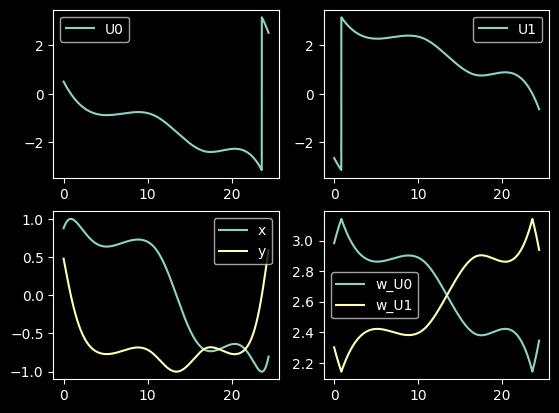

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

chart_regular, chart_antipodal = s1.charts

traj_regular = traj.intrinsic[chart_regular]
traj_antipodal = traj.intrinsic[chart_antipodal]

ax1.plot(traj.time, traj_regular, label=chart_regular)
ax1.legend()

ax2.plot(traj.time, traj_antipodal, label=chart_antipodal)
ax2.legend()

ax3.plot(traj.time, traj.extrinsic, label=["x", "y"])
ax3.legend()

traj_regular_weights = s1.intrinsic_weights_batch(chart_regular, torch.tensor(traj.intrinsic[chart_regular]))
traj_antipodal_weights = s1.intrinsic_weights_batch(chart_antipodal, torch.tensor(traj.intrinsic[chart_antipodal]))

ax4.plot(traj.time, traj_regular_weights, label=f"w_{chart_regular}")
ax4.plot(traj.time, traj_antipodal_weights, label=f"w_{chart_antipodal}")
ax4.legend()